In [1]:
import torch
import matplotlib.pyplot as plt
from models.mlp import run

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
path = "./normalized_images"

# Hyperparameters
# Additionally, set test flag to True to run on test set after training, which will print the test loss and accuracy.
num_epochs = 20
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=True)

-- MLP | Epochs: 20 | LR: 0.0001
Epoch 1/20 - Train Loss: 0.9098, Eval Loss: 0.2358
Epoch 2/20 - Train Loss: 0.3504, Eval Loss: 0.2467
Epoch 3/20 - Train Loss: 0.3050, Eval Loss: 0.2473
Epoch 4/20 - Train Loss: 0.2689, Eval Loss: 0.2282
Epoch 5/20 - Train Loss: 0.2513, Eval Loss: 0.2154
Epoch 6/20 - Train Loss: 0.2374, Eval Loss: 0.2292
Epoch 7/20 - Train Loss: 0.2280, Eval Loss: 0.2147
Epoch 8/20 - Train Loss: 0.2375, Eval Loss: 0.2127
Epoch 9/20 - Train Loss: 0.2314, Eval Loss: 0.2084
Epoch 10/20 - Train Loss: 0.2239, Eval Loss: 0.2044
Epoch 11/20 - Train Loss: 0.2228, Eval Loss: 0.2021
Epoch 12/20 - Train Loss: 0.2297, Eval Loss: 0.2020
Epoch 13/20 - Train Loss: 0.2221, Eval Loss: 0.2243
Epoch 14/20 - Train Loss: 0.2256, Eval Loss: 0.1989
Epoch 15/20 - Train Loss: 0.2135, Eval Loss: 0.2045
Epoch 16/20 - Train Loss: 0.2205, Eval Loss: 0.2037
Epoch 17/20 - Train Loss: 0.2150, Eval Loss: 0.1982
Epoch 18/20 - Train Loss: 0.2158, Eval Loss: 0.1983
Epoch 19/20 - Train Loss: 0.2146, Eval L

# Training / Evaluation of MLP Classifier

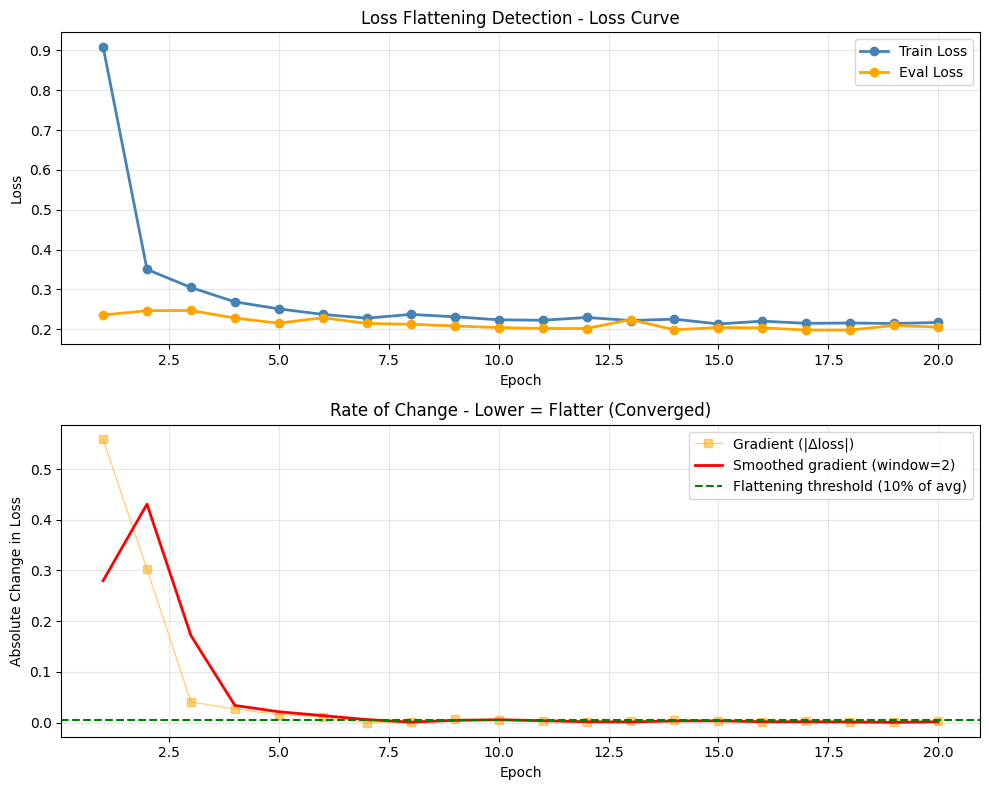


✓ Loss appears to flatten starting around epoch 8


In [4]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, eval_losses, window_size=2)

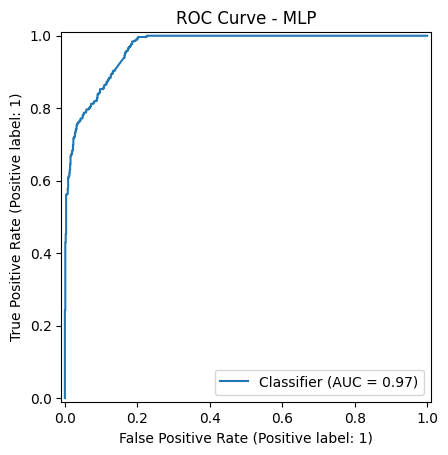

In [5]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - MLP")
plt.show()

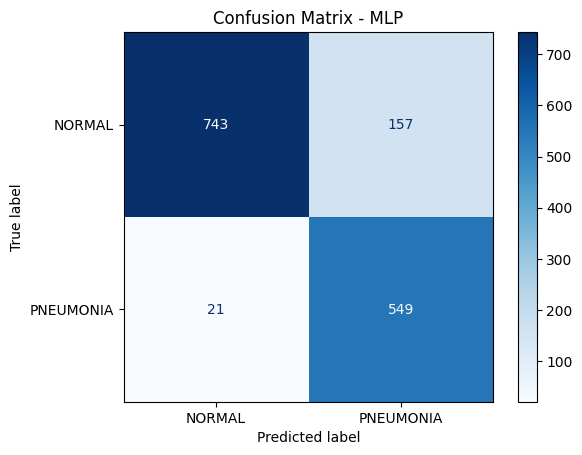

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()

# Testing Results of MLP Classifier

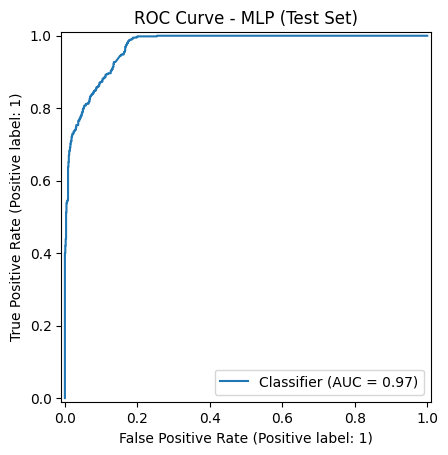

In [7]:
RocCurveDisplay.from_predictions(test_labels, test_preds)
plt.title("ROC Curve - MLP (Test Set)")
plt.show()

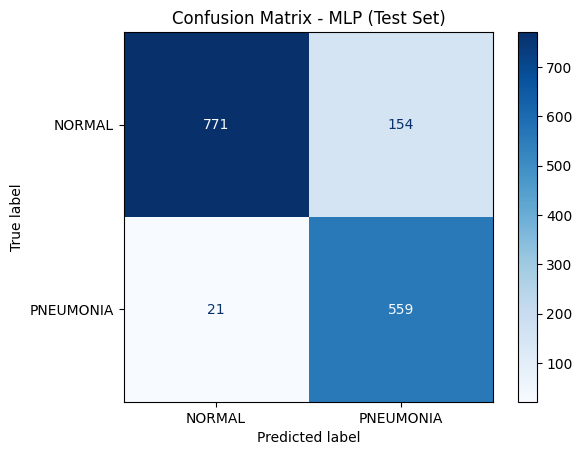

In [8]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP (Test Set)")
plt.show()